In [ ]:
!pip install lifelines shap

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=7a778b7c2453e5e278e1714d4f599e0328c0c7f729255a3a06efc2744f731aa4
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


## 데이터 로드 및 기본 확인

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import shap
from lifelines import KaplanMeierFitter, CoxPHFitter

# 데이터 로드 (파일 경로가 다를 경우 수정)
df_cohort = pd.read_csv("/content/sample_data/01_users_cohort.csv")
df_train = pd.read_csv("/content/sample_data/03_dormancy_train.csv")
df_survival = pd.read_csv("/content/sample_data/06_survival.csv")

print(f"학습 데이터 형태: {df_train.shape}")
print(f"휴면(1) vs 활성(0) 분포:\n{df_train['is_dormant'].value_counts()}")

학습 데이터 형태: (1061, 14)
휴면(1) vs 활성(0) 분포:
is_dormant
1    692
0    369
Name: count, dtype: int64



## EDA 및 코호트 리텐션 분석

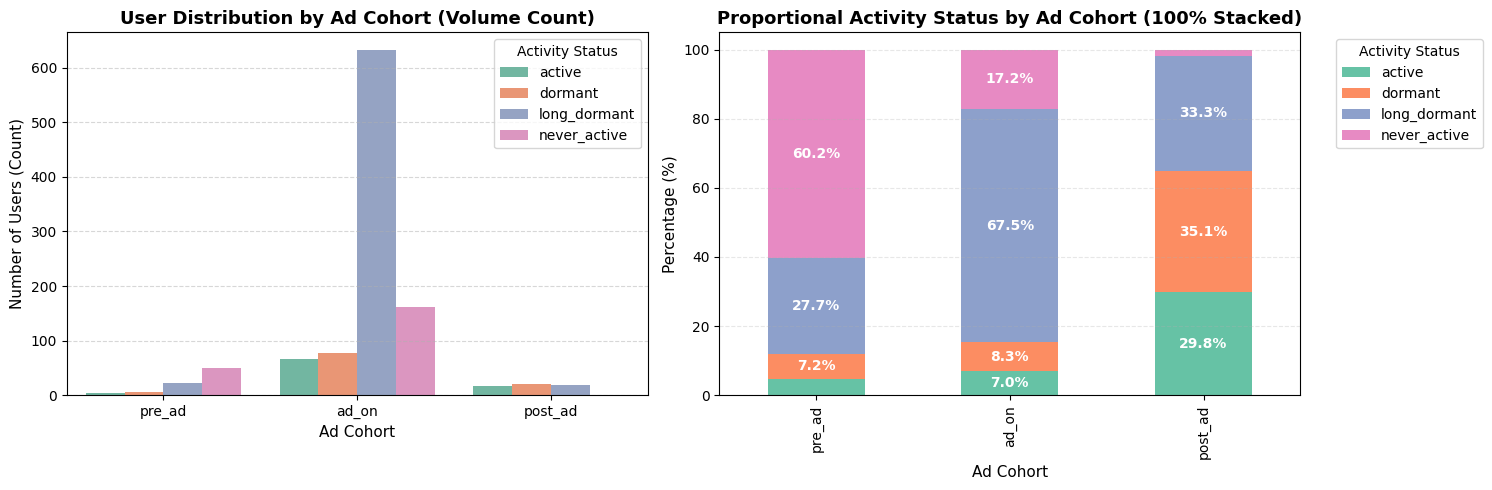

             [Monthly Cohort Activity Status Summary]             
activity_status     active  dormant  long_dormant  never_active
signup_month_clean                                             
2025-07                  4        6            23            50
2025-08                  6       10            56            71
2025-09                  7       12           125            28
2025-10                 25       20           221            39
2025-11                 19       19           157            23
2025-12                  9       17            74             0
2026-01                  5        4            15             0
2026-02                  1        4             4             0
2026-03                  0        5             0             1
2026-04                  7        7             0             0
2026-05                  4        0             0             0


In [9]:
# 가입 월 데이터를 읽기 쉬운 YYYY-MM 포맷으로 변경
df_cohort['signup_month_clean'] = pd.to_datetime(df_cohort['signup_cohort_month']).dt.strftime('%Y-%m')

# 분석의 일관성을 위해 유입 채널(ad_cohort)과 활동 상태(activity_status)의 순서 정의
cohort_order = ['pre_ad', 'ad_on', 'post_ad']
status_order = ['active', 'dormant', 'long_dormant', 'never_active']

# 한 화면에 두 그래프를 그리기 위해 figure 선언
plt.figure(figsize=(15, 5))

# --- [Graph 1: Volume Count (User Count)] ---
plt.subplot(1, 2, 1)
sns.countplot(data=df_cohort, x='ad_cohort', hue='activity_status',
              order=cohort_order, hue_order=status_order, palette='Set2')
plt.title("User Distribution by Ad Cohort (Volume Count)", fontsize=13, weight='bold')
plt.xlabel("Ad Cohort", fontsize=11)
plt.ylabel("Number of Users (Count)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Activity Status")

# --- [Graph 2: 100% Stacked Bar (Percentage)] ---
# 크로스탭 생성 후 인덱스 기준으로 100% 정규화(Normalize) 수행
cohort_pct = pd.crosstab(df_cohort['ad_cohort'], df_cohort['activity_status'], normalize='index') * 100
cohort_pct = cohort_pct.reindex(index=cohort_order, columns=status_order)

plt.subplot(1, 2, 2)
colors = sns.color_palette('Set2', len(status_order))
ax = cohort_pct.plot(kind='bar', stacked=True, ax=plt.gca(), color=colors)
plt.title("Proportional Activity Status by Ad Cohort (100% Stacked)", fontsize=13, weight='bold')
plt.xlabel("Ad Cohort", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)

# 막대 내부에 실제 % 수치 표기 (5% 이상인 유의미한 비중만 텍스트 노출)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 5:
        ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                ha='center', va='center', color='white', weight='bold', fontsize=10)

plt.legend(title="Activity Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# --- [텍스트 통계 테이블 요약 출력] ---
print("="*60)
print("             [Monthly Cohort Activity Status Summary]             ")
print("="*60)
monthly_summary = pd.crosstab(df_cohort['signup_month_clean'], df_cohort['activity_status'])
print(monthly_summary)

- 광고를 통해 유저수가 증가했지만 서비스에는 정착하지 못한 모습

## 휴면 예측 분류
* **알고리즘**: Random Forest Classifier
* **목적**: 가입 후 첫 7일간의 행동 데이터를 인풋으로 주었을 때, 이 유저가 향후 휴면할지 여부를 예측하고 모델의 내부 의사결정 기준을 시각화(SHAP)하여 **Aha Moment**를 발굴합니다.

Random Forest Model ROC-AUC Score: 0.5759
              precision    recall  f1-score   support

           0       0.53      0.35      0.42        74
           1       0.71      0.83      0.77       139

    accuracy                           0.67       213
   macro avg       0.62      0.59      0.59       213
weighted avg       0.65      0.67      0.65       213



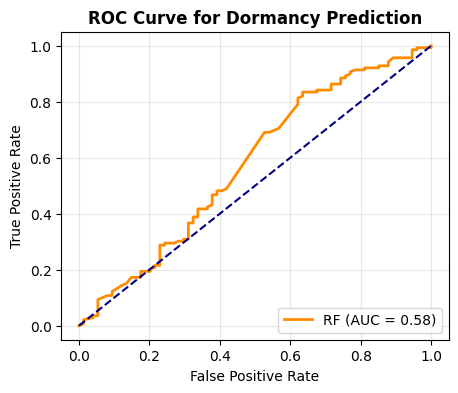

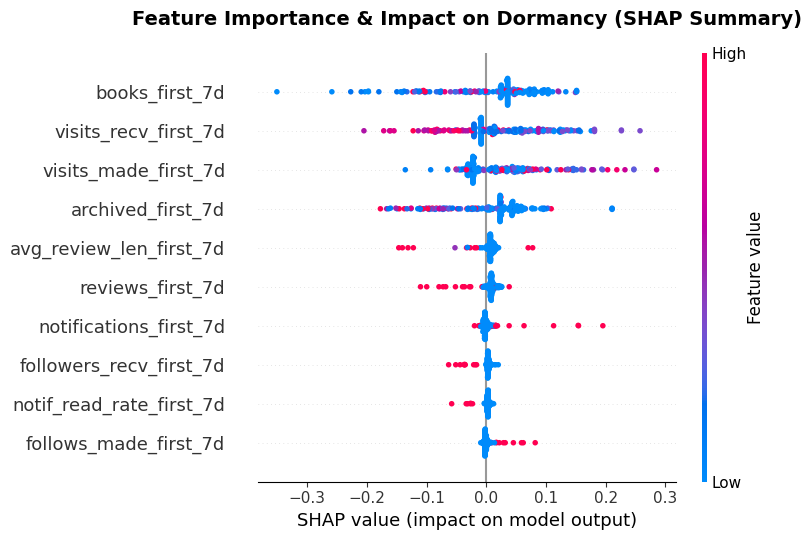

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import shap

# 1. 데이터 로드 및 전처리
df_train = pd.read_csv("/content/sample_data/03_dormancy_train.csv")

# 모델 학습에 불필요한 식별자, 타임스탬프 및 범주형 결측치가 있는 job 컬럼 제외
X = df_train.drop(columns=['user_id', 'signup_at', 'job', 'is_dormant'])
y = df_train['is_dormant']

# 2. Train / Test 데이터 분할 (클래스 비율 유지를 위해 stratify 적용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. 모델 생성 및 학습
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 4. 모델 평가 및 ROC Curve 출력
y_pred_proba = model.predict_proba(X_test)[:, 1]
print("="*60)
print(f"Random Forest Model ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("="*60)
print(classification_report(y_test, model.predict(X_test)))

# ROC 곡선 시각화
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'RF (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve for Dormancy Prediction', fontsize=12, weight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 5. SHAP 가치 산출 및 에러 보정 시각화
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP 버전 및 차원 변경에 대응하는 구조 자동 보정
if isinstance(shap_values, np.ndarray):
    if shap_values.ndim == 3:
        shap_values_plot = shap_values[:, :, 1]  # Class 1 (Dormant) 기준 추출
    else:
        shap_values_plot = shap_values
elif isinstance(shap_values, list):
    shap_values_plot = shap_values[1]            # 구버전 대응
else:
    shap_values_plot = shap_values

# SHAP Summary Plot 출력
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_plot, X_test, show=False)
plt.title("Feature Importance & Impact on Dormancy (SHAP Summary)", fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

#### 1. 정량적 모델 성능 평가
* **ROC-AUC Score**: `0.5759`
* **분석 결과 진단**: 무작위 분류(0.5)보다 약간 높은 수준으로, 예측 모델로서의 판별력이 낮게 나타났습니다.
* **클래스별 재현율(Recall) 불균형**: 휴면 유저(1)에 대한 재현율은 `0.83`으로 높은 편이나, 활성 유저(0)에 대한 재현율은 `0.35`로 매우 저조합니다. 즉, 모델이 활성 사용자의 특징을 명확히 구분하지 못하고 대다수의 유저를 휴면 위험군으로 보수적으로 판단하고 있습니다.

#### 2. 모델 성능이 낮게 나온 정량적 원인 분석 (Limitation)
* **초기 행동 데이터의 해상도 한계**: 가입 후 단 '첫 7일간'의 정적 수치 지표(등록 책 수, 방문 수 등)만으로는 유저의 장기적인 휴면 의사를 이분법적으로 예측하기에 정보의 총량이 부족함을 뜻합니다.
* **동적 이탈 패턴의 유실**: 유저의 이탈은 특정 시점의 행동 여부(0 또는 1)로만 단정 지을 수 없으며, 앞선 3.1 코호트 분석에서 증명했듯 유입 시기 및 앱 이용 기간에 따라 복합적인 '시간차(Time-lag)'를 두고 발생합니다.


## 보조 생존 분석.

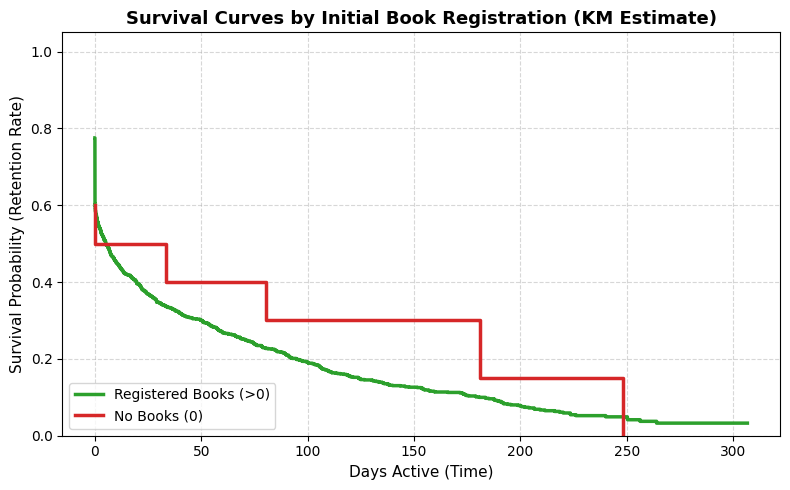

          [Cox Proportional Hazards Model Summary]          


<lifelines.CoxPHFitter: fitted with 1078 total observations, 87 right-censored observations>
             duration col = 'duration_days'
                event col = 'event_dormant'
      baseline estimation = breslow
   number of observations = 1078
number of events observed = 991
   partial log-likelihood = -6011.87
         time fit was run = 2026-05-28 10:57:21 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
total_books           -0.01      0.99      0.00           -0.02           -0.01                0.98                0.99
reviews_count         -0.02      0.98      0.01           -0.05            0.00                0.95                1.00
has_unarchived        -0.38      0.69      0.09           -0.55           -0.20                0.57                0.82
following_count        0.01      1.01      0.02           -0.03            0.05                0.97                1.05
visits_received_count -0.03      0.97      0.01           -0.04           -0.01                0.96                0.99

                       cmp to     z      p  -log2(p)
covariate                                           
total_books              0.00 -3.57 <0.005     11.45
reviews_count            0.00 -1.72   0.09      3.54
has_unarchived           0.00 -4.20 <0.005     15.19
following_count          0.00  0.51   0.61      0.71
visits_received_count    0.00 -4.15 <0.005     14.85
---
Concordance = 0.65
Partial AIC = 12033.74
log-likelihood ratio test = 158.21 on 5 df
-log2(p) of ll-ratio test = 105.05

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter

# 1. 데이터 로드 (경로 확인 필수)
df_survival = pd.read_csv("/content/sample_data/06_survival.csv")

# 2. Kaplan-Meier 생존 곡선 추정 (초기 책 등록 여부에 따른 비교)
kmf = KaplanMeierFitter()

# 가입 첫 주 총 등록 책 수(total_books)가 0보다 큰 경우를 고관여 군으로 정의
has_books = (df_survival['total_books'] > 0)

plt.figure(figsize=(8, 5))

# 책을 등록한 그룹 (Group 1)
kmf.fit(durations=df_survival[has_books]['duration_days'],
        event_observed=df_survival[has_books]['event_dormant'],
        label='Registered Books (>0)')
kmf.plot_survival_function(ci_show=False, color='#2ca02c', lw=2.5)

# 책을 등록하지 않은 그룹 (Group 2)
kmf.fit(durations=df_survival[~has_books]['duration_days'],
        event_observed=df_survival[~has_books]['event_dormant'],
        label='No Books (0)')
kmf.plot_survival_function(ci_show=False, color='#d62728', lw=2.5)

plt.title('Survival Curves by Initial Book Registration (KM Estimate)', fontsize=13, weight='bold')
plt.xlabel('Days Active (Time)', fontsize=11)
plt.ylabel('Survival Probability (Retention Rate)', fontsize=11)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# 3. Cox 비례 위험 모델 실행 (위험비 Hazard Ratio 산출)
print("="*60)
print("          [Cox Proportional Hazards Model Summary]          ")
print("="*60)

# 식별자 및 텍스트 컬럼 정제
df_cox = df_survival.drop(columns=['user_id', 'signup_at', 'job'])

# 모델 적합
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='duration_days', event_col='event_dormant')
cph.print_summary()

# Survival Analysis 결과 해석

## 1. Kaplan-Meier Survival Curve 해석


### 그래프 의미
- Y축: Survival Probability (Retention Rate)
  - 사용자가 서비스에 계속 남아있을 확률
- X축: Days Active (시간)
  - 사용 기간(일)

그래프는 초기 책 등록 여부에 따라 사용자의 유지율 변화를 비교한 것이다.

---

## 2. 그룹별 해석

### ① Registered Books (>0) — 초록색 선
- 초기에 책을 등록한 사용자 그룹
- 전체적으로 더 높은 유지율을 보임
- 시간이 지나도 비교적 완만하게 감소
- 일부 사용자는 장기간 유지됨

#### 의미
초기 책 등록 행동이 사용자 유지(retention)에 긍정적인 영향을 줄 가능성이 있음.

---

### ② No Books (0) — 빨간색 선
- 책 등록을 하지 않은 사용자 그룹
- 유지율이 더 빠르게 감소
- 특정 시점에서 급격한 이탈 발생
- 장기적으로 거의 유지되지 않음

#### 의미
초기 참여 행동이 없는 사용자는 휴면 상태로 전환될 가능성이 높음.

---

## 3. Kaplan-Meier 분석 결론

초기 책 등록 여부는 장기 사용자 유지와 관련성이 있는 것으로 나타났다.

즉,
- 콘텐츠 등록 행동이 있는 사용자는
- 서비스에 더 오래 머무르는 경향을 보였다.

---

# Cox Proportional Hazards Model 해석

## 1. 모델 목적

Cox PH Model은:
> 어떤 사용자 행동이 휴면 위험(Hazard)을 증가 또는 감소시키는지 분석하는 모델이다.

---

## 2. 주요 지표 설명

| 지표 | 의미 |
|---|---|
| coef | 변수 영향 방향 |
| exp(coef) | Hazard Ratio(HR) |
| p-value | 통계적 유의성 |
| HR < 1 | 휴면 위험 감소 |
| HR > 1 | 휴면 위험 증가 |

---

# 3. 변수별 해석

## (1) total_books

| 값 | 결과 |
|---|---|
| coef | -0.01 |
| HR | 0.99 |
| p-value | < 0.005 |

### 해석
- 등록한 책 수가 많을수록 휴면 위험 감소
- HR이 1보다 작으므로 보호 효과 존재

#### 의미
콘텐츠 등록 활동이 활발한 사용자는 장기 유지 가능성이 높다.

---

## (2) has_unarchived

| 값 | 결과 |
|---|---|
| coef | -0.38 |
| HR | 0.69 |
| p-value | < 0.005 |

### 해석
- 아카이브 해제 행동이 있는 사용자는
- 휴면 위험이 약 31% 감소

계산:
```text
1 - 0.69 = 0.31 (31%)

In [12]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# 로지스틱 회귀 테스트
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])

# XGBoost 테스트
xgb_model = XGBClassifier(scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), random_state=42)
xgb_model.fit(X_train, y_train)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"XGBoost AUC: {xgb_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression AUC: 0.5964
Random Forest AUC: 0.5759
XGBoost AUC: 0.5345
